Importing the Dependencies

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, classification_report, confusion_matrix)

from sklearn.preprocessing import StandardScaler

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#loading the dataset to a pandas DataFrame
credit_card_data = pd.read_csv("creditcard.csv")

In [3]:
#first 5 rows of the dataset
credit_card_data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
credit_card_data.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [5]:
#dataset informations
credit_card_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [6]:
#checking the number of missing values in each column
credit_card_data.isnull().sum() 

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [7]:
#Distribution of legit transactions & fraudulent transactions
credit_card_data['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

This dataset is highy unbalanced

0 -> Normal Transaction

1 -> Fraudulent Transaction

In [8]:
#Separating the data for analysis
legit = credit_card_data[credit_card_data.Class==0]
fraud = credit_card_data[credit_card_data.Class==1]

In [9]:
print("Legit:", len(credit_card_data[credit_card_data.Class == 0]))
print("Fraud:", len(credit_card_data[credit_card_data.Class == 1]))

Legit: 284315
Fraud: 492


In [10]:
print(legit.shape)
print(fraud.shape)

(284315, 31)
(492, 31)


In [10]:
#statistical measures of the data
legit.Amount.describe()

count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

In [11]:
fraud.Amount.describe()

count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

In [12]:
#compare the values for both transactions
credit_card_data.groupby('Class').mean()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0,94838.202258,0.008258,-0.006271,0.012171,-0.007860,0.005453,0.002419,0.009637,-0.000987,0.004467,...,-0.000644,-0.001235,-0.000024,0.000070,0.000182,-0.000072,-0.000089,-0.000295,-0.000131,88.291022
1,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,...,0.372319,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321


Under Sampling

Built a sample dataset containing similar distribution of normal transactions and Fraudulent Transactions

Number of Fraudulent Transactions - 492  

In [13]:
legit_sample = legit.sample(n=492)

In [14]:
legit_sample

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
225225,144158.0,-0.776980,0.939229,-3.039308,-0.260068,0.819493,0.557911,1.485782,0.542628,-0.907680,...,0.726139,2.342215,0.134753,-1.311082,-1.256178,-0.331362,0.085363,-0.016539,171.67,0
51358,44910.0,-0.425709,0.970308,1.538736,-0.019139,-0.165046,-0.904415,0.679717,-0.024708,-0.280077,...,-0.232415,-0.659061,0.005633,0.343925,-0.217569,0.073537,0.257519,0.119870,10.58,0
93237,64313.0,-1.890973,2.257613,-0.887107,0.773413,0.088876,-0.795373,0.242363,0.724049,-0.241060,...,-0.083516,-0.120479,-0.133787,-0.558978,0.102964,-0.292498,0.370488,0.318231,19.75,0
34334,37616.0,0.487552,-0.764444,0.665627,2.804002,-0.974258,-0.207236,0.138010,-0.014052,-0.282991,...,0.301078,-0.009863,-0.323455,0.371228,0.224840,0.025462,-0.061570,0.088575,353.71,0
260682,159670.0,2.062455,-0.143429,-1.087553,0.430754,-0.266199,-1.251088,0.093398,-0.259743,0.742562,...,-0.304533,-0.805977,0.358091,0.009822,-0.344277,0.199939,-0.079251,-0.062863,0.89,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66002,51840.0,-1.959866,0.677107,0.820685,-1.382464,0.026193,-0.619171,0.064689,-0.228891,-1.163240,...,-0.177902,-0.438260,-0.039308,-0.516998,0.293095,-0.487595,-0.999659,-0.256904,12.00,0
242565,151546.0,-0.964271,-0.043073,1.297015,-3.133226,-1.004501,-0.302242,-0.637247,0.574619,-2.327870,...,-0.131273,-0.061240,-0.378254,-0.375611,0.674617,-0.114479,0.149058,0.029520,6.00,0
199586,133037.0,0.105772,1.013053,-0.987352,-0.083746,0.186286,-1.142135,0.560521,0.251837,-0.393642,...,0.398583,1.052824,-0.025088,-0.002898,-0.309937,-0.175135,-0.083515,-0.054543,37.11,0
281307,170083.0,2.128714,-0.038313,-1.491326,0.155988,0.457153,-0.513737,0.191210,-0.278844,0.513367,...,-0.345137,-0.814964,0.209978,-1.045409,-0.151330,0.263946,-0.064584,-0.069818,1.29,0


Concatenating two DataFrames

In [15]:
new_dataset = pd.concat([legit_sample,fraud],axis=0)

In [16]:
new_dataset

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
225225,144158.0,-0.776980,0.939229,-3.039308,-0.260068,0.819493,0.557911,1.485782,0.542628,-0.907680,...,0.726139,2.342215,0.134753,-1.311082,-1.256178,-0.331362,0.085363,-0.016539,171.67,0
51358,44910.0,-0.425709,0.970308,1.538736,-0.019139,-0.165046,-0.904415,0.679717,-0.024708,-0.280077,...,-0.232415,-0.659061,0.005633,0.343925,-0.217569,0.073537,0.257519,0.119870,10.58,0
93237,64313.0,-1.890973,2.257613,-0.887107,0.773413,0.088876,-0.795373,0.242363,0.724049,-0.241060,...,-0.083516,-0.120479,-0.133787,-0.558978,0.102964,-0.292498,0.370488,0.318231,19.75,0
34334,37616.0,0.487552,-0.764444,0.665627,2.804002,-0.974258,-0.207236,0.138010,-0.014052,-0.282991,...,0.301078,-0.009863,-0.323455,0.371228,0.224840,0.025462,-0.061570,0.088575,353.71,0
260682,159670.0,2.062455,-0.143429,-1.087553,0.430754,-0.266199,-1.251088,0.093398,-0.259743,0.742562,...,-0.304533,-0.805977,0.358091,0.009822,-0.344277,0.199939,-0.079251,-0.062863,0.89,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279863,169142.0,-1.927883,1.125653,-4.518331,1.749293,-1.566487,-2.010494,-0.882850,0.697211,-2.064945,...,0.778584,-0.319189,0.639419,-0.294885,0.537503,0.788395,0.292680,0.147968,390.00,1
280143,169347.0,1.378559,1.289381,-5.004247,1.411850,0.442581,-1.326536,-1.413170,0.248525,-1.127396,...,0.370612,0.028234,-0.145640,-0.081049,0.521875,0.739467,0.389152,0.186637,0.76,1
280149,169351.0,-0.676143,1.126366,-2.213700,0.468308,-1.120541,-0.003346,-2.234739,1.210158,-0.652250,...,0.751826,0.834108,0.190944,0.032070,-0.739695,0.471111,0.385107,0.194361,77.89,1
281144,169966.0,-3.113832,0.585864,-5.399730,1.817092,-0.840618,-2.943548,-2.208002,1.058733,-1.632333,...,0.583276,-0.269209,-0.456108,-0.183659,-0.328168,0.606116,0.884876,-0.253700,245.00,1


In [17]:
new_dataset.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
225225,144158.0,-0.776980,0.939229,-3.039308,-0.260068,0.819493,0.557911,1.485782,0.542628,-0.907680,...,0.726139,2.342215,0.134753,-1.311082,-1.256178,-0.331362,0.085363,-0.016539,171.67,0
51358,44910.0,-0.425709,0.970308,1.538736,-0.019139,-0.165046,-0.904415,0.679717,-0.024708,-0.280077,...,-0.232415,-0.659061,0.005633,0.343925,-0.217569,0.073537,0.257519,0.119870,10.58,0
93237,64313.0,-1.890973,2.257613,-0.887107,0.773413,0.088876,-0.795373,0.242363,0.724049,-0.241060,...,-0.083516,-0.120479,-0.133787,-0.558978,0.102964,-0.292498,0.370488,0.318231,19.75,0
34334,37616.0,0.487552,-0.764444,0.665627,2.804002,-0.974258,-0.207236,0.138010,-0.014052,-0.282991,...,0.301078,-0.009863,-0.323455,0.371228,0.224840,0.025462,-0.061570,0.088575,353.71,0
260682,159670.0,2.062455,-0.143429,-1.087553,0.430754,-0.266199,-1.251088,0.093398,-0.259743,0.742562,...,-0.304533,-0.805977,0.358091,0.009822,-0.344277,0.199939,-0.079251,-0.062863,0.89,0


In [18]:
new_dataset.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
279863,169142.0,-1.927883,1.125653,-4.518331,1.749293,-1.566487,-2.010494,-0.882850,0.697211,-2.064945,...,0.778584,-0.319189,0.639419,-0.294885,0.537503,0.788395,0.292680,0.147968,390.00,1
280143,169347.0,1.378559,1.289381,-5.004247,1.411850,0.442581,-1.326536,-1.413170,0.248525,-1.127396,...,0.370612,0.028234,-0.145640,-0.081049,0.521875,0.739467,0.389152,0.186637,0.76,1
280149,169351.0,-0.676143,1.126366,-2.213700,0.468308,-1.120541,-0.003346,-2.234739,1.210158,-0.652250,...,0.751826,0.834108,0.190944,0.032070,-0.739695,0.471111,0.385107,0.194361,77.89,1
281144,169966.0,-3.113832,0.585864,-5.399730,1.817092,-0.840618,-2.943548,-2.208002,1.058733,-1.632333,...,0.583276,-0.269209,-0.456108,-0.183659,-0.328168,0.606116,0.884876,-0.253700,245.00,1
281674,170348.0,1.991976,0.158476,-2.583441,0.408670,1.151147,-0.096695,0.223050,-0.068384,0.577829,...,-0.164350,-0.295135,-0.072173,-0.450261,0.313267,-0.289617,0.002988,-0.015309,42.53,1


In [19]:
new_dataset['Class'].value_counts()

Class
0    492
1    492
Name: count, dtype: int64

In [20]:
new_dataset.groupby('Class').mean()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0,97730.436992,-0.008249,-0.009018,0.110399,0.045685,0.083932,-0.062451,-0.051599,0.004336,-0.047772,...,-0.028934,0.039637,0.053240,0.022563,-0.005898,-0.039294,-0.029429,0.000930,0.011864,69.011829
1,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,...,0.372319,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321


Splitting the data into Features and Targets

In [23]:
X = new_dataset.drop('Class', axis=1)
Y = new_dataset['Class']

In [24]:
print(X)

            Time        V1        V2        V3        V4        V5        V6  \
225225  144158.0 -0.776980  0.939229 -3.039308 -0.260068  0.819493  0.557911   
51358    44910.0 -0.425709  0.970308  1.538736 -0.019139 -0.165046 -0.904415   
93237    64313.0 -1.890973  2.257613 -0.887107  0.773413  0.088876 -0.795373   
34334    37616.0  0.487552 -0.764444  0.665627  2.804002 -0.974258 -0.207236   
260682  159670.0  2.062455 -0.143429 -1.087553  0.430754 -0.266199 -1.251088   
...          ...       ...       ...       ...       ...       ...       ...   
279863  169142.0 -1.927883  1.125653 -4.518331  1.749293 -1.566487 -2.010494   
280143  169347.0  1.378559  1.289381 -5.004247  1.411850  0.442581 -1.326536   
280149  169351.0 -0.676143  1.126366 -2.213700  0.468308 -1.120541 -0.003346   
281144  169966.0 -3.113832  0.585864 -5.399730  1.817092 -0.840618 -2.943548   
281674  170348.0  1.991976  0.158476 -2.583441  0.408670  1.151147 -0.096695   

              V7        V8        V9  .

In [25]:
print(Y)

225225    0
51358     0
93237     0
34334     0
260682    0
         ..
279863    1
280143    1
280149    1
281144    1
281674    1
Name: Class, Length: 984, dtype: int64


Split the data into Training data and Testing data

In [26]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [27]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,stratify=Y,random_state=2)

In [28]:
print(X.shape, X_train.shape, X_test.shape)

(984, 30) (787, 30) (197, 30)


Model Training: LogisticRegression

In [29]:
model = LogisticRegression(max_iter=1000)

In [30]:
#Training the logistic regression model with Training data
model.fit(X_train,Y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Model Evaluation: Accuracy Score

In [31]:
#Accuracy on training data
X_train_prediction = model.predict(X_train)
training_data_accuracy = accuracy_score(X_train_prediction,Y_train)

In [32]:
print("Accuracy on training data:", training_data_accuracy)

Accuracy on training data: 0.9593392630241423


In [33]:
#Accuracy on test data
x_test_prediction = model.predict(X_test)
test_data_accuracy = accuracy_score(x_test_prediction,Y_test)

In [34]:
print("Accuracy on testing data:", test_data_accuracy)

Accuracy on testing data: 0.9035532994923858


In [36]:
precision = precision_score(Y_test, x_test_prediction)
recall = recall_score(Y_test, x_test_prediction)
f1 = f1_score(Y_test, x_test_prediction)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.9247311827956989
Recall: 0.8775510204081632
F1 Score: 0.900523560209424


In [37]:
print("\nClassification Report:\n")
print(classification_report(Y_test, x_test_prediction))


Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.93      0.91        99
           1       0.92      0.88      0.90        98

    accuracy                           0.90       197
   macro avg       0.90      0.90      0.90       197
weighted avg       0.90      0.90      0.90       197



In [38]:
cm = confusion_matrix(Y_test, x_test_prediction)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[92  7]
 [12 86]]


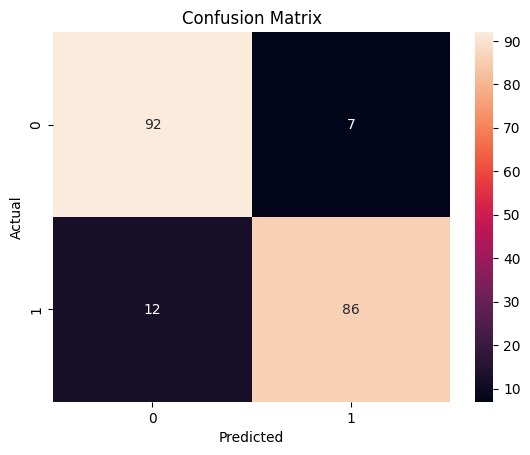

In [39]:
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()